In [27]:
%pip install -q pandas matplotlib scikit-learn statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error as mse

import Tratar_Dados.limpar_Texto as lt
import Tratar_Dados.salvar_Df as sd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
try:
    df = pd.read_csv(r'/workspaces/Projeto_Series_Temporais/Data/daily-minimum-temperatures-in-me.csv', sep = ',')
    display(df.head(5))

except FileNotFoundError:
    print("\nERRO: Arquivo não encontrado!")
    print("Para corrigir:")
    print("1. Vá até a pasta *Data* no painel lateral da IDE.")
    print("2. Clique com o botão direito no arquivo desejado.")
    print("3. Clique em **Copiar o caminho**.")
    print("4. Cole o caminho no local abaixo:")
    print("\ndf_original = pd.read_csv(r'COLE_O_CAMINHO_AQUI')\n")

except Exception as e:
    print("\nOcorreu o erro: ", e)

,Date,Daily minimum temperatures
0,1/1/1981,20.7
1,1/2/1981,17.9
2,1/3/1981,18.8
3,1/4/1981,14.6
4,1/5/1981,15.8


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Date                        3650 non-null   str  
 1   Daily minimum temperatures  3650 non-null   str  
dtypes: str(2)
memory usage: 57.2 KB


In [31]:
df = lt.limpar_Texto(df)

df = lt.converter_tipo_coluna(df)

In [32]:
display(df)

,Daily minimum temperatures
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5


In [33]:
dataTest = df.iloc[1:,:]
dataTest = dataTest[::-1]

display(dataTest)

,Daily minimum temperatures
Date,
1990-12-31,13.0
1990-12-30,15.7
1990-12-29,13.5
1990-12-28,13.6
1990-12-27,14.0
...,...
1981-01-06,15.8
1981-01-05,15.8
1981-01-04,14.6


# Modelo SVR

In [34]:
trainSplit = 0.6
validSplit= 0.2

serie = dataTest
dataset = serie.values
trainSize = int(np.floor(trainSplit*len(dataset)))
validSize = int(np.floor(validSplit*len(dataset)))

maxData = np.max(dataset)
minData = np.min(dataset)

ndataset  = (dataset  - minData)/(maxData-minData)


datasetSeries = pd.Series(ndataset.flatten())
dimension = 12
stepahead = 1

datasetShifted = pd.concat([datasetSeries.shift(i) for i in range(dimension+stepahead) ],axis=1)

train = (datasetShifted.iloc[dimension:trainSize,1:])
trainTarget = (datasetShifted.iloc[dimension:trainSize,0])

valid = datasetShifted.iloc[trainSize:(validSize+trainSize),1:]
validTarget = datasetShifted.iloc[trainSize:(validSize+trainSize),0]

test = datasetShifted.iloc[(validSize+trainSize):,1:]
testTarget = datasetShifted.iloc[(validSize+trainSize):,0]



g=(10.0)**np.arange(-5,3,1) #10
e = (10.0)**np.arange(-4,-1,1) # 10
c=(10.0)**np.arange(-2,3,1)#10
bestValue = 10**100000
erroval = []
param=[]
bestSVR=0
for i in g:
    for j in e:
        for k in c:

            mySVR = SVR(C=k,gamma=i,epsilon=j)
            mySVR.fit(train,trainTarget)

            predVals = mySVR.predict(valid)
            erro = mse(predVals,validTarget)
            erroval.append(erro)
            param.append((i,j,k))
            if erro<bestValue:
                bestValue=erro
                bestSVR = mySVR

In [35]:
pred_test = bestSVR.predict(test)

last_value = testTarget.iloc[-1].astype(float)
last_window = test.iloc[-1,:].tolist()


window = []
window.append(last_value)
window.extend(last_window[:dimension-1])

day_30_prediction = bestSVR.predict(np.array(window).reshape(1,-1))
day_30_prediction = (day_30_prediction[0])*(maxData-minData) + minData

pred_test = bestSVR.predict(test)

In [36]:
pred_test_desnorm = (pred_test * (maxData - minData)) + minData
testTarget_desnorm = (testTarget.values * (maxData - minData)) + minData

residuos_svr = testTarget_desnorm - pred_test_desnorm

## Graficos para SVR

### Gráfico de Linhas e de Comparação de previsões

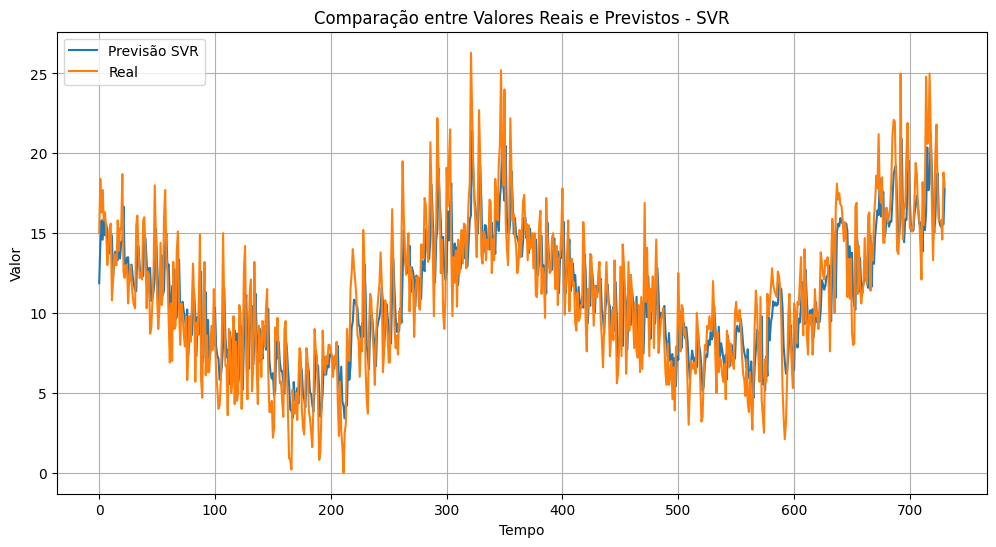

In [37]:
plt.figure(figsize=(12,6))

plt.plot(pred_test_desnorm,
         label='Previsão SVR')

plt.plot(testTarget_desnorm,
         label='Real')

plt.title('Comparação entre Valores Reais e Previstos - SVR')

plt.xlabel('Tempo')
plt.ylabel('Valor')

plt.legend()
plt.grid(True)

plt.show()

### Gráfico de Autocorrelação

<Figure size 1200x600 with 0 Axes>

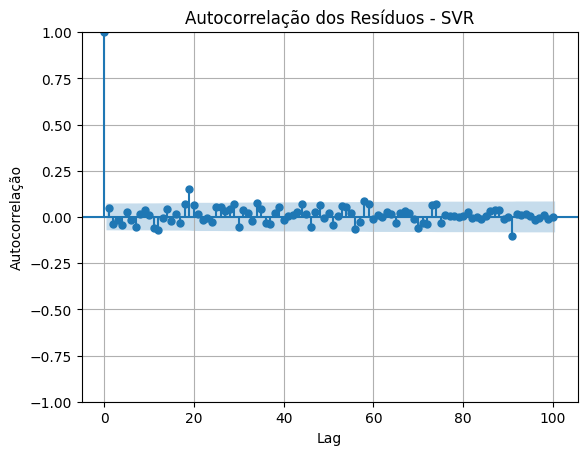

In [38]:
plt.figure(figsize=(12,6))

plot_acf(residuos_svr,
         lags=100)

plt.title('Autocorrelação dos Resíduos - SVR')

plt.xlabel('Lag')
plt.ylabel('Autocorrelação')

plt.grid(True)

plt.show()

## Modelo MLP

In [39]:
trainSplit = 0.6
validSplit = 0.2

# Série temporal
serie = dataTest

dataset = serie.values

# Normalização
maxData = np.max(dataset)
minData = np.min(dataset)

ndataset = (dataset - minData) / (maxData - minData)

# Converter para Series
datasetSeries = pd.Series(ndataset.flatten())

# Janela temporal
dimension = 12

# Previsão t+1
stepahead = 1

# Construção dos lags
datasetShifted = pd.concat(
    [datasetSeries.shift(i)
     for i in range(dimension + stepahead)],
    axis=1
)

# Remover NaN
datasetShifted = datasetShifted.dropna()

# Divisão treino/validação/teste
trainSize = int(np.floor(trainSplit * len(datasetShifted)))
validSize = int(np.floor(validSplit * len(datasetShifted)))

train = datasetShifted.iloc[:trainSize, 1:]
trainTarget = datasetShifted.iloc[:trainSize, 0]

valid = datasetShifted.iloc[
    trainSize:(trainSize + validSize), 1:
]

validTarget = datasetShifted.iloc[
    trainSize:(trainSize + validSize), 0
]

test = datasetShifted.iloc[
    (trainSize + validSize):, 1:
]

testTarget = datasetShifted.iloc[
    (trainSize + validSize):, 0
]

# Converter para numpy
train = train.values
valid = valid.values
test = test.values

trainTarget = trainTarget.values
validTarget = validTarget.values
testTarget = testTarget.values

# Modelo MLP
mlp = MLPRegressor(
    hidden_layer_sizes=(100,100),
    activation='relu',
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

# Treinamento
mlp.fit(train, trainTarget)

# Validação
predVals = mlp.predict(valid)

# MSE
erro = mse(validTarget, predVals)

print("MSE Validação:", erro)

# Melhor modelo
bestMLP = mlp
bestValue = erro

# Previsão teste
pred_test = bestMLP.predict(test)

# Desnormalização
pred_test_desnorm = (
    pred_test * (maxData - minData)
) + minData

testTarget_desnorm = (
    testTarget * (maxData - minData)
) + minData

MSE Validação: 0.008957116660081992


In [40]:
predTest = mlp.predict(test)

last_value = float(testTarget[-1])
last_window = test[-1, :].tolist()

window = test[-1, :]

day30_prediction = mlp.predict(window.reshape(1, -1))
day30_prediction = day30_prediction[0] * (maxData - minData) + minData

In [41]:
# Desnormalizar os valores reais
testTarget_atualizado = testTarget * (maxData - minData) + minData

# Desnormalizar a previsão
predTest_atualizado = predTest * (maxData - minData) + minData

# Converter para 1D
predTest_atualizado = predTest_atualizado.flatten()
testTarget_atualizado = testTarget_atualizado.flatten()

residuos_mlp = testTarget_desnorm - pred_test_desnorm

## Graficos para MLP

### Gráfico de linhas e de comparação de previsões

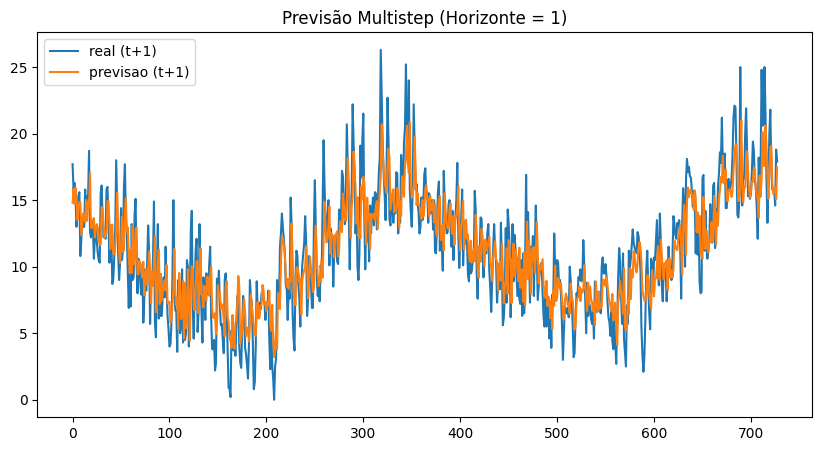

In [42]:
plt.figure(figsize=(10,5))
plt.plot(testTarget_atualizado, label='real (t+1)')
plt.plot(predTest_atualizado, label='previsao (t+1)')
plt.title('Previsão Multistep (Horizonte = 1)')
plt.legend()
plt.show()

### Gráfico de Autocorrelação

<Figure size 1200x600 with 0 Axes>

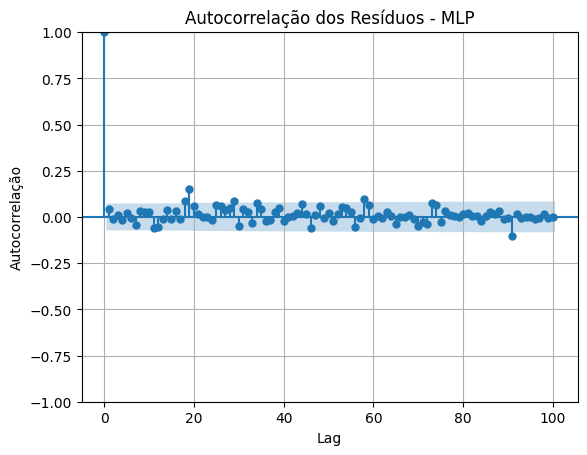

In [43]:
plt.figure(figsize=(12,6))

plot_acf(residuos_mlp,
         lags=100)

plt.title('Autocorrelação dos Resíduos - MLP')

plt.xlabel('Lag')
plt.ylabel('Autocorrelação')

plt.grid(True)

plt.show()

## Modelo AR

In [44]:
trainSplit = 0.6
validSplit = 0.2

# Série temporal
serie = dataTest.iloc[:,0]

dataset = serie.values

# =========================
# Normalização
# =========================

maxData = np.max(dataset)
minData = np.min(dataset)

ndataset = (dataset - minData) / (maxData - minData)

# Converter para Series
datasetSeries = pd.Series(ndataset.flatten())

# =========================
# Parâmetros temporais
# =========================

dimension = 12
stepahead = 1

# =========================
# Construção da base temporal
# =========================

datasetShifted = pd.concat(
    [datasetSeries.shift(i)
     for i in range(dimension + stepahead)],
    axis=1
)

# Remover NaN
datasetShifted = datasetShifted.dropna()

# =========================
# Divisão treino/validação/teste
# =========================

trainSize = int(np.floor(trainSplit * len(datasetShifted)))
validSize = int(np.floor(validSplit * len(datasetShifted)))

# Targets
trainTarget = datasetShifted.iloc[:trainSize, 0]

validTarget = datasetShifted.iloc[
    trainSize:(trainSize + validSize), 0
]

testTarget = datasetShifted.iloc[
    (trainSize + validSize):, 0
]

# =========================
# Modelo AR
# =========================

ar_model = AutoReg(
    trainTarget,
    lags=dimension,
    old_names=False
)

# Treinamento
ar_fit = ar_model.fit()

# =========================
# Previsão validação
# =========================

predVals = ar_fit.predict(
    start=len(trainTarget),
    end=len(trainTarget) + len(validTarget) - 1,
    dynamic=False
)

# Remover possíveis NaNs
predVals = predVals.dropna()

# Ajustar tamanho
validTarget = validTarget[:len(predVals)]

# =========================
# MSE validação
# =========================

erro = mse(validTarget, predVals)

print("MSE Validação:", erro)

# =========================
# Previsão teste
# =========================

# Concatenar treino + validação
train_valid = pd.concat([
    trainTarget,
    validTarget
])

# Novo modelo treinado
bestAR = AutoReg(
    train_valid,
    lags=dimension,
    old_names=False
).fit()

# Previsão teste
pred_test = bestAR.predict(
    start=len(train_valid),
    end=len(train_valid) + len(testTarget) - 1,
    dynamic=False
)

MSE Validação: 0.023170401854352672


In [45]:
pred_test_desnorm = (
    pred_test * (maxData - minData)
) + minData

testTarget_desnorm = (
    testTarget.values * (maxData - minData)
) + minData

residuos_ar = testTarget_desnorm - pred_test_desnorm

## Graficos para MLP

### Gráfico de linhas e de comparação de previsões

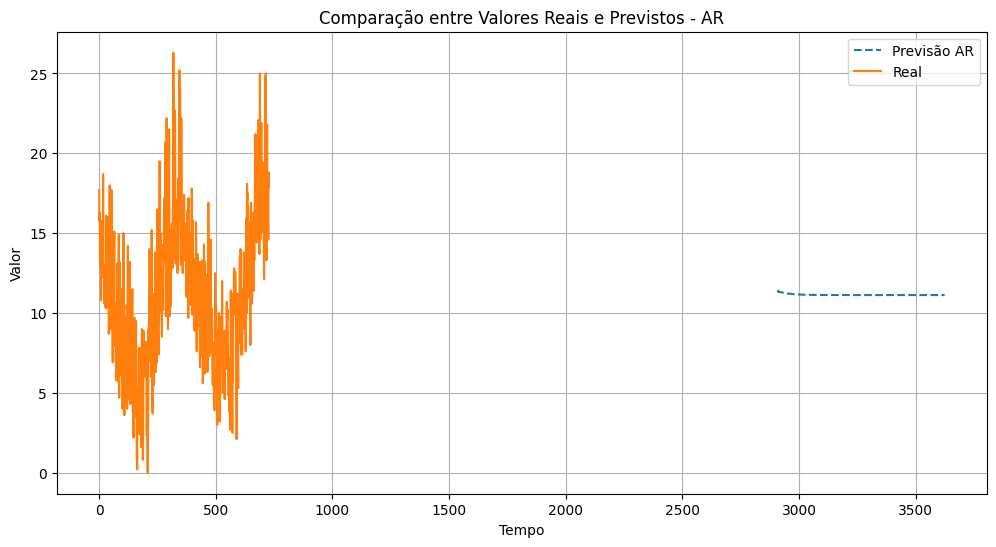

In [46]:
plt.figure(figsize=(12,6))

plt.plot(pred_test_desnorm,
         '--',
         label='Previsão AR')

plt.plot(testTarget_desnorm,
         label='Real')

plt.title('Comparação entre Valores Reais e Previstos - AR')

plt.xlabel('Tempo')
plt.ylabel('Valor')

plt.legend()
plt.grid(True)

plt.show()

### Gráfico de Autocorrelação

<Figure size 1200x600 with 0 Axes>

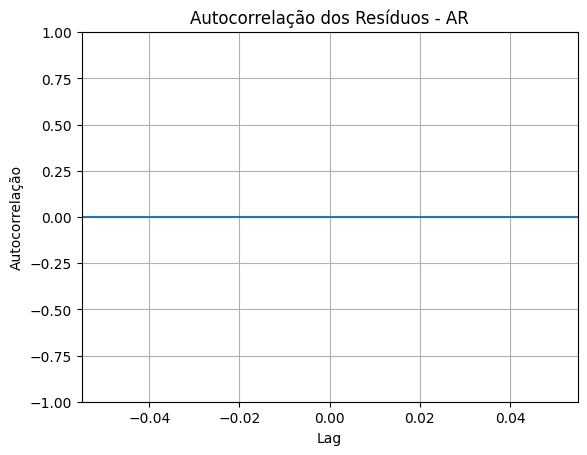

In [47]:
plt.figure(figsize=(12,6))

plot_acf(residuos_ar,
         lags=100)

plt.title('Autocorrelação dos Resíduos - AR')

plt.xlabel('Lag')
plt.ylabel('Autocorrelação')

plt.grid(True)

plt.show()